Estudo de Ablação

Um estudo de ablação é um método de pesquisa em IA/aprendizado de máquina que remove ou desativa sistematicamente componentes (características, camadas ou módulos) de um modelo para medir sua contribuição individual para o desempenho final. Ele ajuda a identificar componentes necessários, reduz a complexidade do modelo e valida se melhorias específicas realmente aprimoram os resultados, garantindo uma "degradação gradual". O termo tem raízes na neuropsicologia, referindo-se à remoção de partes do cérebro para entender suas funções. No contexto de IA, é o processo de "remover" ou desativar sistematicamente partes de um modelo treinado para observar como essa exclusão afeta o resultado final. Os estudos de ablação garantem que o modelo não está apenas "decorando" os dados, mas sim que cada parte dele está contribuindo ativamente para a aprendizagem. São essenciais para justificar escolhas arquiteturais em artigos científicos e projetos de engenharia
Principais Objetivos
Identificar Importância: Determinar quais partes do modelo são cruciais e quais são irrelevantes.
Explicar Causalidade: Investigar se uma melhoria no desempenho se deve realmente a um novo componente proposto ou a outros fatores.
Simplificar Modelos: Ajudar a remover componentes desnecessários para reduzir a complexidade e o tempo de treinamento.
Entender falhas: Investigar o impacto de cada componente nos resultados de falha do sistema
Exemplos Comuns
Redes Neurais (Deep Learning): Remover camadas específicas (ex: camadas de dropout ou camadas ocultas) em redes convolucionais profundas.
Arquitetura LSTM: Remover portas de esquecimento (forget gates) ou atualização para medir o impacto na capacidade da rede de gerenciar informações.
Detecção de Objetos: Remover o módulo de localização para verificar o quanto ele contribui para a precisão geral, mantendo o extrator de características intacto.
Feature Engineering: Remover características (variáveis) de entrada específicas para avaliar a importância de cada dado na predição
Com a CNN feita na APS anterior, escolha um componente que você considera essencial no seu modelo e realize um estudo de ablação com ele. Este componente pode ser um procedimento como a regularização empregada, ou seja, você pode estudar a influência de uma técnica de  regularização específica no desempenho de sua CNN ligando e desligando esta técnica. Você também pode escolher componentes da CNN como camadas específicas, testando se a sua presença/ausência impacta no seu desempenho preditivo. Use o mesmo conjunto de dados e as mesmas métricas usadas na APS anterior. 

O que submeter nesta atividade?

Documento com o estudo de ablação da CNN que você implementou. Ele deve responder às seguintes perguntas:
Qual o componente escolhido para o estudo?
Quais os resultados com e sem este componente?
Qual sua opinião sobre o impacto da presença deste componente?
Link para o repositório com o código-fonte das CNNs e do estudo de ablação.

DESAFIO: Criar gráficos que mostrem a influência do componente escolhido no desempenho da CNN.


Best trial MNIST by accuracy: acurácia=0.9899, complexidade=16177696.0000, params={'num_conv_layers': 3, 'out_channels_layer_0': 8, 'out_channels_layer_1': 64, 'out_channels_layer_2': 32, 'kernel_size': 5, 'stride_conv': 1, 'padding_conv': 1, 'use_pooling': True, 'activation_function_conv': 'leaky_relu', 'use_dropout_conv': True, 'dropout_rate_conv': 0.3458079375584162, 'num_fc_layers': 2, 'fc_units_0': 256, 'fc_units_1': 256, 'activation_function_fc': 'relu', 'use_dropout_fc': False, 'batch_size': 32, 'learning_rate': 0.0017250862192012557, 'optimizer': 'sgd', 'use_weight_decay': True, 'weight_decay': 3.866993164285028e-06}


Best trial CIFAR10 by accuracy: acurácia=0.6420, complexidade=14275200.0000, params={'num_conv_layers': 2, 'out_channels_layer_0': 32, 'out_channels_layer_1': 32, 'kernel_size': 3, 'stride_conv': 1, 'padding_conv': 2, 'use_pooling': False, 'activation_function_conv': 'relu', 'use_dropout_conv': False, 'num_fc_layers': 2, 'fc_units_0': 32, 'fc_units_1': 128, 'activation_function_fc': 'tanh', 'use_dropout_fc': True, 'dropout_rate_fc': 0.19583925932804302, 'batch_size': 32, 'learning_rate': 0.0001977314899753934, 'optimizer': 'sgd', 'use_weight_decay': True, 'weight_decay': 9.585545204800447e-05}


## Estudo de ablação

Esta seção consolida o experimento da terceira atividade usando os resultados já gerados em `ablation_study_results.json`. O componente analisado foi o `dropout` na CNN da atividade anterior, comparando duas variantes: com dropout e sem dropout.

### Carregar resultados e montar a tabela comparativa

O código abaixo lê os artefatos salvos pelos experimentos e organiza as métricas principais para o relatório.

In [1]:
import json
from pathlib import Path
import matplotlib.pyplot as plt

results_path = Path('ablation_study_results.json')
with results_path.open('r', encoding='utf-8') as f:
    ablation_results = json.load(f)

ablation_results

{'with_dropout': {'accuracy': 0.9849,
  'params': 2363130,
  'flops': 3974528.0,
  'train_time_sec': 1492.4433360099792,
  'model_path': '/home/bruno/PROJETOS-IF687/terceira_atividade/models/best_with.pth'},
 'without_dropout': {'accuracy': 0.9857,
  'params': 2363130,
  'flops': 3974528.0,
  'train_time_sec': 272.0590784549713,
  'model_path': '/home/bruno/PROJETOS-IF687/terceira_atividade/models/best_without.pth'}}

In [2]:
import pandas as pd

comparison_df = pd.DataFrame([
    {
        'variant': 'with_dropout',
        'accuracy': ablation_results['with_dropout']['accuracy'],
        'params': ablation_results['with_dropout']['params'],
        'flops': ablation_results['with_dropout']['flops'],
        'train_time_sec': ablation_results['with_dropout']['train_time_sec'],
    },
    {
        'variant': 'without_dropout',
        'accuracy': ablation_results['without_dropout']['accuracy'],
        'params': ablation_results['without_dropout']['params'],
        'flops': ablation_results['without_dropout']['flops'],
        'train_time_sec': ablation_results['without_dropout']['train_time_sec'],
    },
])
comparison_df

,variant,accuracy,params,flops,train_time_sec
0,with_dropout,0.9849,2363130,3974528.0,1492.443336
1,without_dropout,0.9857,2363130,3974528.0,272.059078


### Gráficos comparativos

Os gráficos abaixo resumem o impacto do dropout sobre acurácia, tempo de treino e complexidade do modelo.

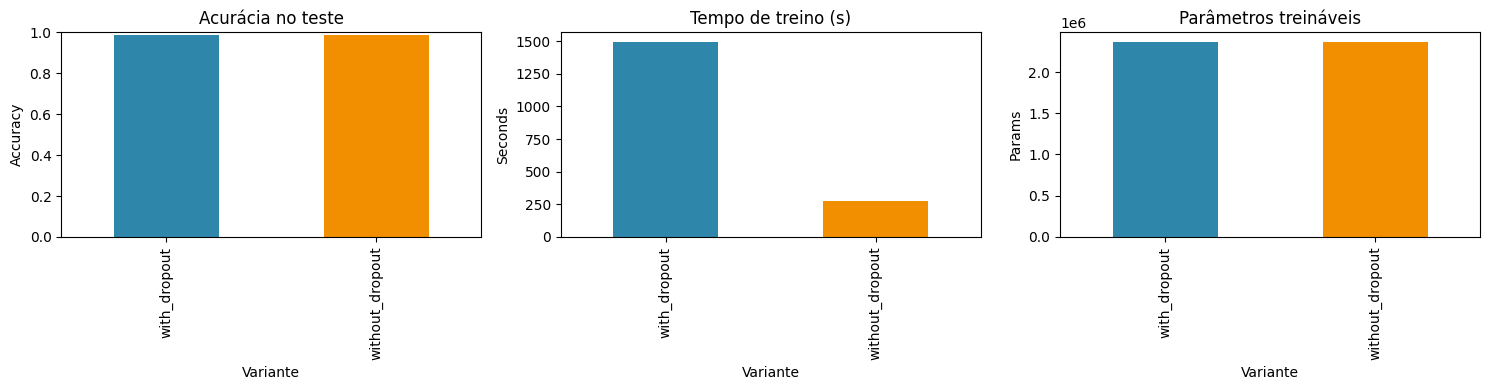

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

comparison_df.plot.bar(x='variant', y='accuracy', ax=axes[0], legend=False, color=['#2E86AB', '#F18F01'])
axes[0].set_title('Acurácia no teste')
axes[0].set_ylim(0, 1)
axes[0].set_xlabel('Variante')
axes[0].set_ylabel('Accuracy')

comparison_df.plot.bar(x='variant', y='train_time_sec', ax=axes[1], legend=False, color=['#2E86AB', '#F18F01'])
axes[1].set_title('Tempo de treino (s)')
axes[1].set_xlabel('Variante')
axes[1].set_ylabel('Seconds')

comparison_df.plot.bar(x='variant', y='params', ax=axes[2], legend=False, color=['#2E86AB', '#F18F01'])
axes[2].set_title('Parâmetros treináveis')
axes[2].set_xlabel('Variante')
axes[2].set_ylabel('Params')

plt.tight_layout()
plt.show()

### Conclusão para o relatório

Com base nos resultados obtidos, a variante sem dropout apresentou desempenho ligeiramente superior em acurácia e menor tempo de treino. Como a quantidade de parâmetros e os FLOPs permaneceram iguais, a diferença observada está ligada ao comportamento de regularização durante o treinamento, e não à complexidade estrutural da rede.

Em um texto de relatório, isso pode ser interpretado como evidência de que, para esta configuração específica e neste recorte experimental, o dropout não trouxe ganho de generalização suficiente para compensar o custo de treinamento.

In [4]:
csv_path = Path('ablation_study_results.csv')
comparison_df.to_csv(csv_path, index=False)
print(f'Results exported to {csv_path.resolve()}')

with_dropout = ablation_results['with_dropout']
without_dropout = ablation_results['without_dropout']

summary_text = (
    f"Sem dropout: accuracy={without_dropout['accuracy']:.4f}, ",
    f"params={without_dropout['params']}, flops={without_dropout['flops']}, ",
    f"train_time_sec={without_dropout['train_time_sec']:.2f}.\n"
    f"Com dropout: accuracy={with_dropout['accuracy']:.4f}, ",
    f"params={with_dropout['params']}, flops={with_dropout['flops']}, ",
    f"train_time_sec={with_dropout['train_time_sec']:.2f}.\n"
    "Conclusão: nesta execução, a variante sem dropout obteve acurácia ligeiramente maior e treinou mais rápido."
 )

print(''.join(summary_text))

Results exported to /home/bruno/PROJETOS-IF687/terceira_atividade/ablation_study_results.csv
Sem dropout: accuracy=0.9857, params=2363130, flops=3974528.0, train_time_sec=272.06.
Com dropout: accuracy=0.9849, params=2363130, flops=3974528.0, train_time_sec=1492.44.
Conclusão: nesta execução, a variante sem dropout obteve acurácia ligeiramente maior e treinou mais rápido.


## Ablação adicional: número de camadas convolucionais

Para ampliar o estudo, esta seção compara duas arquiteturas mantendo os demais hiperparâmetros fixos:
- Variante A: 2 camadas convolucionais
- Variante B: 3 camadas convolucionais

Assim avaliamos o impacto direto de profundidade convolucional no desempenho preditivo e no custo de treino.

In [5]:
import torch
from torchvision import datasets
from torchvision.transforms import v2
from torch.utils.data import Subset
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

from ablation_utils import set_seed, CNNParameters, run_ablation_variant, split_train_val_dataset

set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

# Ajuste para acelerar validações locais em CPU.
# Coloque QUICK = False para executar no conjunto completo.
QUICK = True

transform_mnist = v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
training_data = datasets.MNIST(root='./../datasets', train=True, download=True, transform=transform_mnist)
test_data = datasets.MNIST(root='./../datasets', train=False, download=True, transform=transform_mnist)
train_data, val_data = split_train_val_dataset(training_data, val_size=1.0/6.0)

if QUICK:
    train_data = Subset(train_data.dataset, train_data.indices[:5000])
    val_data = Subset(val_data.dataset, val_data.indices[:1000])
    print(f'QUICK mode ativo: train={len(train_data)}, val={len(val_data)}, test={len(test_data)}')
else:
    print(f'FULL mode: train={len(train_data)}, val={len(val_data)}, test={len(test_data)}')

Device: cpu
QUICK mode ativo: train=5000, val=1000, test=10000


In [6]:
image_h = training_data[0][0].shape[1]
image_w = training_data[0][0].shape[2]

common_kwargs = dict(
    stride_conv_layers=1,
    input_channels=1,
    use_pooling=True,
    padding_conv_layer=1,
    dilatation=1,
    bias=True,
    kernel_size=3,
    kernel_stride=1,
    kernel_padding=0,
    kernel_dilatation=1,
    activation_function_conv='leaky_relu',
    fully_connected_layers_list=[128],
    activation_function_fully_connected='relu',
    dropout_rate_fully_connected=0.0,
    dropout_rate_conv=0.0,
    output_size_fully_connected=10,
    image_size_height=image_h,
    image_size_width=image_w,
)

params_2conv = CNNParameters(
    num_conv_layers=2,
    out_channels_list=[8, 32],
    **common_kwargs,
 )

params_3conv = CNNParameters(
    num_conv_layers=3,
    out_channels_list=[8, 32, 32],
    **common_kwargs,
 )

num_epochs = 2 if QUICK else 8
patience = 2
lr = 1e-3
batch_size = 64

conv_results = {}
conv_results['2_conv_layers'], conv_hist_2 = run_ablation_variant(
    params_2conv, train_data, test_data, val_data, batch_size, num_epochs, patience, lr,
    save_path='models/best_2conv.pth', device=device, verbose=True, compute_flops=True
 )

conv_results['3_conv_layers'], conv_hist_3 = run_ablation_variant(
    params_3conv, train_data, test_data, val_data, batch_size, num_epochs, patience, lr,
    save_path='models/best_3conv.pth', device=device, verbose=True, compute_flops=True
 )

conv_results

Epoch 1/2, Train Loss: 0.7654, Val Loss: 0.3643, Val Metric: 0.889
Epoch 2/2, Train Loss: 0.2221, Val Loss: 0.1668, Val Metric: 0.945


Unsupported operator aten::leaky_relu encountered 2 time(s)
Unsupported operator aten::max_pool2d encountered 2 time(s)


Epoch 1/2, Train Loss: 0.6319, Val Loss: 0.2709, Val Metric: 0.92
Epoch 2/2, Train Loss: 0.1675, Val Loss: 0.1546, Val Metric: 0.951


Unsupported operator aten::leaky_relu encountered 3 time(s)
Unsupported operator aten::max_pool2d encountered 3 time(s)


{'2_conv_layers': {'accuracy': 0.951,
  'params': 2363130,
  'flops': 3974528.0,
  'train_time_sec': 10.10739803314209,
  'model_path': 'models/best_2conv.pth'},
 '3_conv_layers': {'accuracy': 0.9536,
  'params': 1995546,
  'flops': 8906112.0,
  'train_time_sec': 11.972352743148804,
  'model_path': 'models/best_3conv.pth'}}

In [7]:
conv_df = pd.DataFrame([
    {
        'variant': '2_conv_layers',
        'accuracy': conv_results['2_conv_layers']['accuracy'],
        'params': conv_results['2_conv_layers']['params'],
        'flops': conv_results['2_conv_layers']['flops'],
        'train_time_sec': conv_results['2_conv_layers']['train_time_sec'],
    },
    {
        'variant': '3_conv_layers',
        'accuracy': conv_results['3_conv_layers']['accuracy'],
        'params': conv_results['3_conv_layers']['params'],
        'flops': conv_results['3_conv_layers']['flops'],
        'train_time_sec': conv_results['3_conv_layers']['train_time_sec'],
    },
])
conv_df

,variant,accuracy,params,flops,train_time_sec
0,2_conv_layers,0.9510,2363130,3974528.0,10.107398
1,3_conv_layers,0.9536,1995546,8906112.0,11.972353


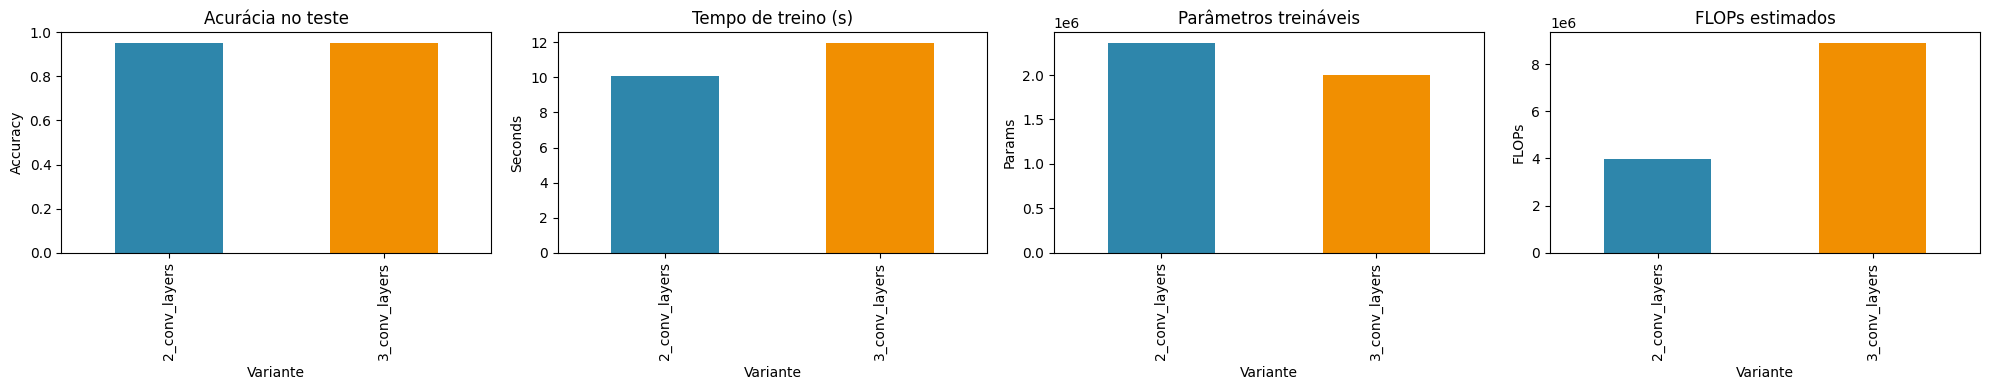

Results exported to /home/bruno/PROJETOS-IF687/terceira_atividade/ablation_conv_layers_results.csv


In [8]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

conv_df.plot.bar(x='variant', y='accuracy', ax=axes[0], legend=False, color=['#2E86AB', '#F18F01'])
axes[0].set_title('Acurácia no teste')
axes[0].set_ylim(0, 1)
axes[0].set_xlabel('Variante')
axes[0].set_ylabel('Accuracy')

conv_df.plot.bar(x='variant', y='train_time_sec', ax=axes[1], legend=False, color=['#2E86AB', '#F18F01'])
axes[1].set_title('Tempo de treino (s)')
axes[1].set_xlabel('Variante')
axes[1].set_ylabel('Seconds')

conv_df.plot.bar(x='variant', y='params', ax=axes[2], legend=False, color=['#2E86AB', '#F18F01'])
axes[2].set_title('Parâmetros treináveis')
axes[2].set_xlabel('Variante')
axes[2].set_ylabel('Params')

conv_df.plot.bar(x='variant', y='flops', ax=axes[3], legend=False, color=['#2E86AB', '#F18F01'])
axes[3].set_title('FLOPs estimados')
axes[3].set_xlabel('Variante')
axes[3].set_ylabel('FLOPs')

plt.tight_layout()
plt.show()

conv_csv_path = Path('ablation_conv_layers_results.csv')
conv_df.to_csv(conv_csv_path, index=False)
print(f'Results exported to {conv_csv_path.resolve()}')